In [1]:
import cv2
import numpy
import glob
from matplotlib import pyplot
%matplotlib inline

In [2]:
pref = "../../openmvcam-firmware/spect_imgs/473385600/473385600*"
csvdirs = glob.glob(pref)
csvs = {csvdir[-5]: numpy.loadtxt(csvdir, delimiter=',') for csvdir in csvdirs}
# for wl, img in csvs.items():
#     csvs[wl][1::2] = img[1::2, ::-1]
# print(csvs)

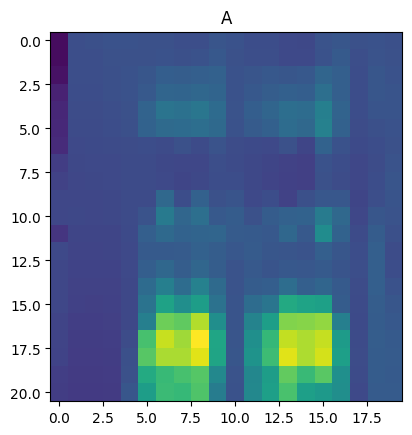

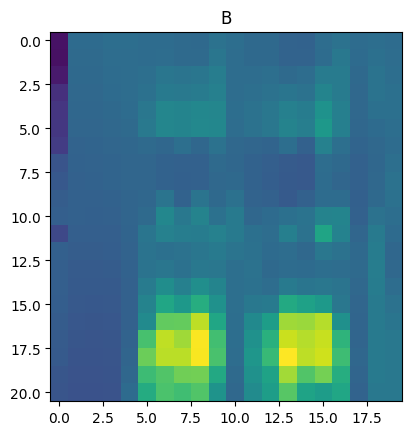

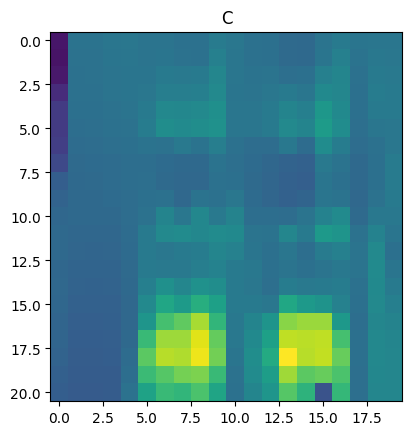

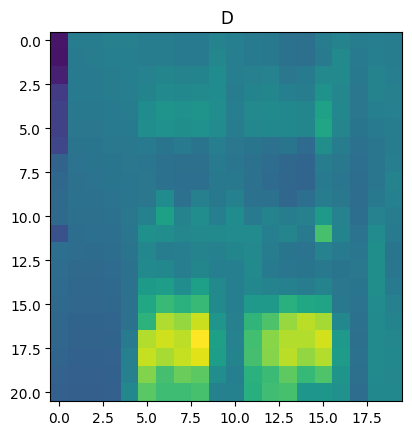

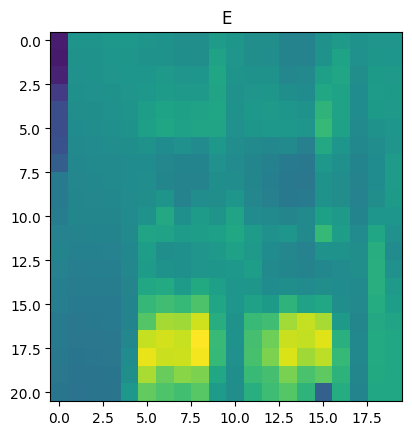

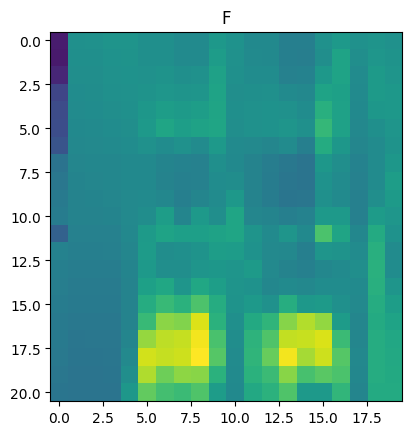

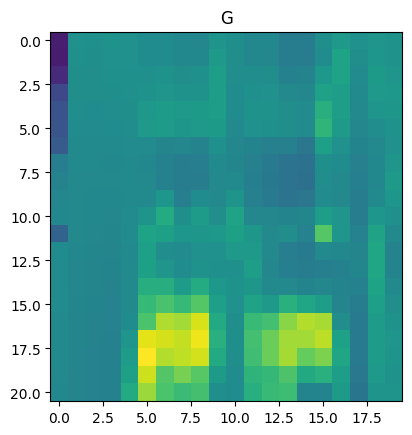

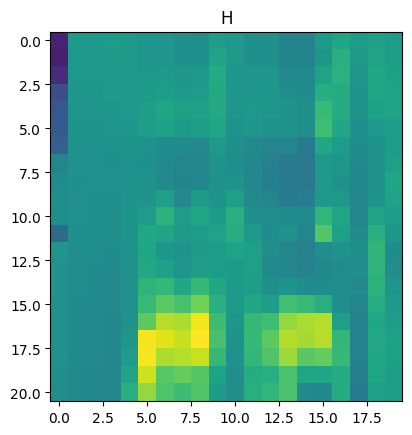

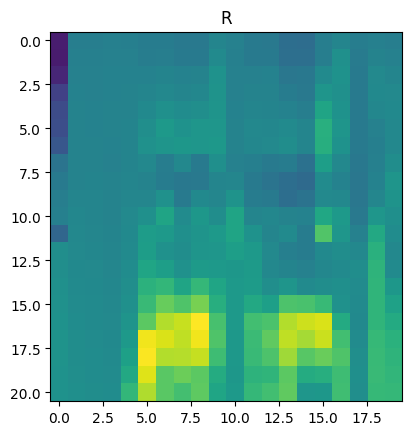

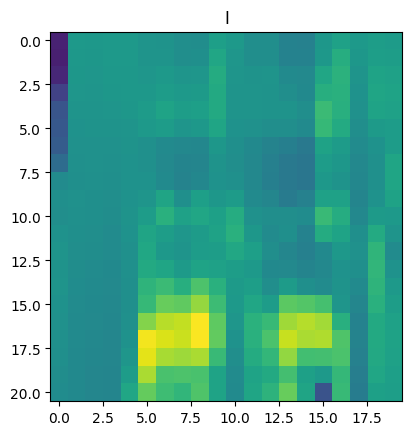

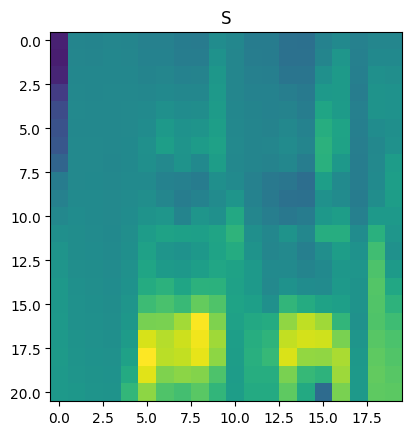

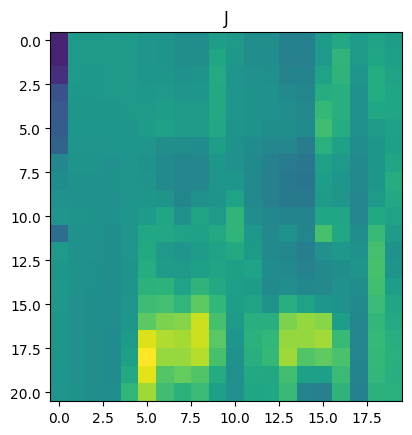

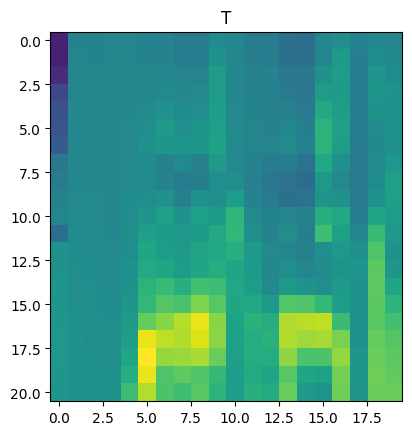

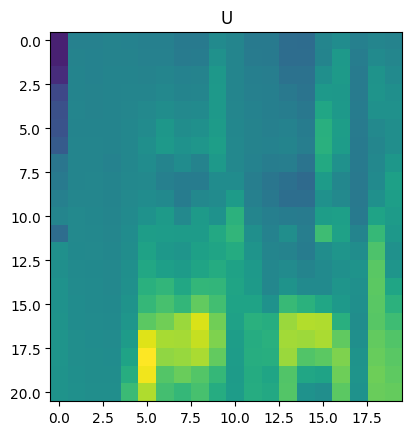

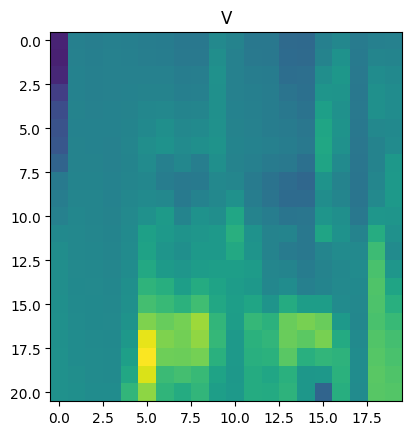

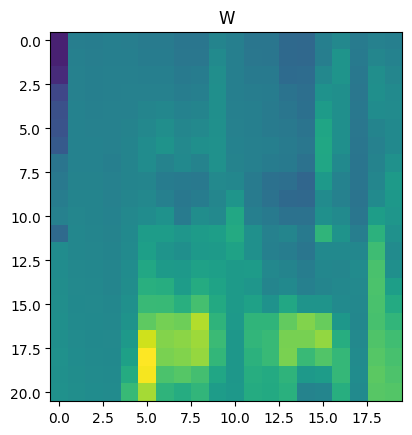

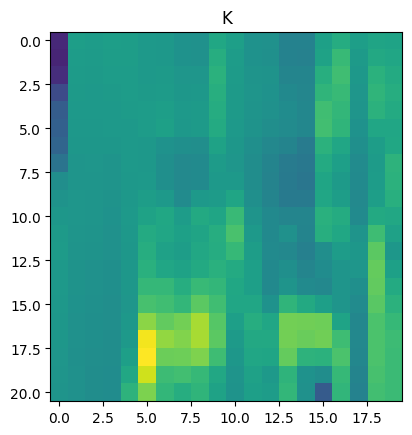

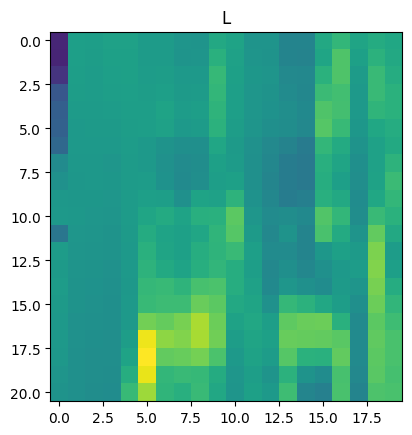

In [5]:
totalmax = max([numpy.max(img) for _, img in csvs.items()])
for wl, img in csvs.items():
    if numpy.max(img) != 0:
        imgnorm = (img * (255 / numpy.max(img))).astype(numpy.uint8)
    else:
        print("caught 0 division")
        imgnorm = img.astype(numpy.uint8)
    imgnorm = cv2.flip(cv2.rotate(imgnorm, cv2.ROTATE_90_COUNTERCLOCKWISE), 0)
    # cv2.imshow('', imgnorm)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    pyplot.imshow(imgnorm, vmin=0, vmax=255)
    pyplot.title(wl)
    pyplot.show()
